# Real Estate Investment Advisor: Predicting Property Profitability & Future Value

## Data Preprocessing

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
raw_df = pd.read_csv(r'Datasets/india_housing_prices.csv')
raw_df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [3]:
raw_df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors    

In [4]:
raw_df.describe()

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,125000.500000,2.999396,2749.813216,254.586854,0.130597,2006.520012,14.966800,15.503004,18.479988,5.499860,5.498016
std,72168.927986,1.415521,1300.606954,141.349921,0.130747,9.808575,8.948047,8.671618,9.808575,2.878639,2.871860
min,1.000000,1.000000,500.000000,10.000000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,62500.750000,2.000000,1623.000000,132.550000,0.050000,1998.000000,7.000000,8.000000,10.000000,3.000000,3.000000
50%,125000.500000,3.000000,2747.000000,253.870000,0.090000,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,187500.250000,4.000000,3874.000000,376.880000,0.160000,2015.000000,23.000000,23.000000,27.000000,8.000000,8.000000
max,250000.000000,5.000000,5000.000000,500.000000,0.990000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


In [5]:
#### 1. What is the total number of rows and columns in the dataset?
rows,cols = raw_df.shape
print(f"The dataset has {rows} rows and {cols} columns.")

The dataset has 250000 rows and 23 columns.


In [6]:
### 2. What are the data types of each column?
for column, dtype in raw_df.dtypes.items():
    print(f"The column '{column}' has the following data type: {dtype}")

The column 'ID' has the following data type: int64
The column 'State' has the following data type: object
The column 'City' has the following data type: object
The column 'Locality' has the following data type: object
The column 'Property_Type' has the following data type: object
The column 'BHK' has the following data type: int64
The column 'Size_in_SqFt' has the following data type: int64
The column 'Price_in_Lakhs' has the following data type: float64
The column 'Price_per_SqFt' has the following data type: float64
The column 'Year_Built' has the following data type: int64
The column 'Furnished_Status' has the following data type: object
The column 'Floor_No' has the following data type: int64
The column 'Total_Floors' has the following data type: int64
The column 'Age_of_Property' has the following data type: int64
The column 'Nearby_Schools' has the following data type: int64
The column 'Nearby_Hospitals' has the following data type: int64
The column 'Public_Transport_Accessibilit

In [7]:
### 4. Which columns contain missing values?
for column, null_count in raw_df.isnull().sum().items():
    print(f"The column '{column}' has {null_count} null values.")

The column 'ID' has 0 null values.
The column 'State' has 0 null values.
The column 'City' has 0 null values.
The column 'Locality' has 0 null values.
The column 'Property_Type' has 0 null values.
The column 'BHK' has 0 null values.
The column 'Size_in_SqFt' has 0 null values.
The column 'Price_in_Lakhs' has 0 null values.
The column 'Price_per_SqFt' has 0 null values.
The column 'Year_Built' has 0 null values.
The column 'Furnished_Status' has 0 null values.
The column 'Floor_No' has 0 null values.
The column 'Total_Floors' has 0 null values.
The column 'Age_of_Property' has 0 null values.
The column 'Nearby_Schools' has 0 null values.
The column 'Nearby_Hospitals' has 0 null values.
The column 'Public_Transport_Accessibility' has 0 null values.
The column 'Parking_Space' has 0 null values.
The column 'Security' has 0 null values.
The column 'Amenities' has 0 null values.
The column 'Facing' has 0 null values.
The column 'Owner_Type' has 0 null values.
The column 'Availability_Status'

In [8]:
### 11. Are there duplicate rows in the dataset?
print("Exact duplicate rows:", raw_df.duplicated().sum())

Exact duplicate rows: 0


In [9]:
print(raw_df['City'].unique())
print(raw_df['Property_Type'].unique())
print(raw_df['Property_Type'].unique())
print(raw_df['Property_Type'].unique())

['Chennai' 'Pune' 'Ludhiana' 'Jodhpur' 'Jaipur' 'Durgapur' 'Coimbatore'
 'Bilaspur' 'New Delhi' 'Ranchi' 'Warangal' 'Bangalore' 'Nagpur' 'Lucknow'
 'Silchar' 'Dehradun' 'Noida' 'Gaya' 'Jamshedpur' 'Ahmedabad' 'Hyderabad'
 'Faridabad' 'Amritsar' 'Kolkata' 'Dwarka' 'Vishakhapatnam' 'Bhopal'
 'Indore' 'Haridwar' 'Mysore' 'Patna' 'Raipur' 'Vijayawada' 'Trivandrum'
 'Kochi' 'Surat' 'Gurgaon' 'Mangalore' 'Cuttack' 'Bhubaneswar' 'Guwahati'
 'Mumbai']
['Apartment' 'Independent House' 'Villa']
['Apartment' 'Independent House' 'Villa']
['Apartment' 'Independent House' 'Villa']


### Create target column Future_Price_5Y

In [10]:
rng = np.random.default_rng(42)
city_tiers = {
    **{c: 0.11 for c in ['Mumbai','Bangalore','Gurgaon','Pune','Hyderabad','New Delhi','Noida']},
    **{c: 0.09 for c in ['Chennai','Ahmedabad','Kolkata','Surat','Jaipur','Kochi',
                         'Trivandrum','Coimbatore','Indore','Vishakhapatnam','Dwarka','Faridabad']},
    **{c: 0.07 for c in ['Lucknow','Bhopal','Nagpur','Bhubaneswar','Mysore','Mangalore',
                         'Vijayawada','Warangal','Dehradun','Guwahati','Raipur','Ranchi',
                         'Amritsar','Ludhiana','Jodhpur','Patna']},
    **{c: 0.055 for c in ['Gaya','Silchar','Bilaspur','Durgapur','Jamshedpur','Cuttack','Haridwar']},
}
type_effect = {'Villa': 0.010, 'Independent House': 0.007, 'Apartment': 0.0}
def age_effect(age):
    return -0.0015 * np.clip(age, 0, 40)
r_signal = (
    raw_df['City'].map(city_tiers)
    + raw_df['Property_Type'].map(type_effect)
    + age_effect(raw_df['Age_of_Property'])
)
NOISE_SD = 0.018
r_noise = rng.normal(0, NOISE_SD, size=len(raw_df))
r = r_signal.to_numpy() + r_noise
r = np.clip(r, 0.0, None) 
YEARS = 5
raw_df['Growth_Rate_Annual'] = r
raw_df['Future_Price_5Y'] = raw_df['Price_in_Lakhs'] * (1 + r) ** YEARS

### Create target column Good_Investment

In [11]:
raw_df['Amenities_Count'] = raw_df['Amenities'].str.split(',').str.len()
city_median = raw_df.groupby('City')['Price_per_SqFt'].transform('median')
cond1 = raw_df['Price_per_SqFt'] <= city_median

cond2 = raw_df['BHK'] >= 3

cond3 = raw_df['Availability_Status'] == 'Ready_to_Move'
cond4 = (raw_df['Parking_Space'] == 'Yes') & (raw_df['Amenities_Count'] >= 3)
score = cond1.astype(int) + cond2.astype(int) + cond3.astype(int) + cond4.astype(int)
raw_df['Good_Investment'] = (score >= 3).astype(int)
print(raw_df['Good_Investment'].value_counts())
print(raw_df['Good_Investment'].value_counts(normalize=True).round(3))

Good_Investment
0    181105
1     68895
Name: count, dtype: int64
Good_Investment
0    0.724
1    0.276
Name: proportion, dtype: float64


## Exploratory Data Analysis (EDA)

### 1–5: Price & Size Analysis

#### 1. What is the distribution of property prices?

The skew of property pices is 0.008205884031130036


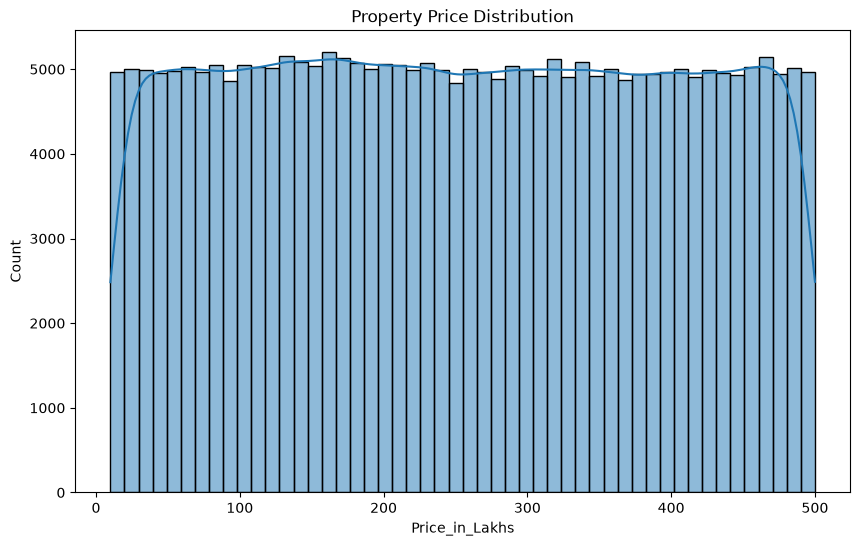

In [12]:
print(f"The skew of property pices is {raw_df['Price_in_Lakhs'].skew()}")
plt.figure(figsize=(10,6))
plt.title("Property Price Distribution")
sns.histplot(data=raw_df,x="Price_in_Lakhs",bins=50, kde=True)
plt.show()

#### Interpretation:
The skewness of the property price distribution is 0.0082, which is very close to zero. This indicates that property prices are approximately normally distributed with an almost symmetric distribution. There is no significant positive or negative skewness, suggesting that extreme high or low property prices do not substantially distort the overall distribution.

#### 2. What is the distribution of property sizes?

The skew of property pices is 0.0007959572519020365


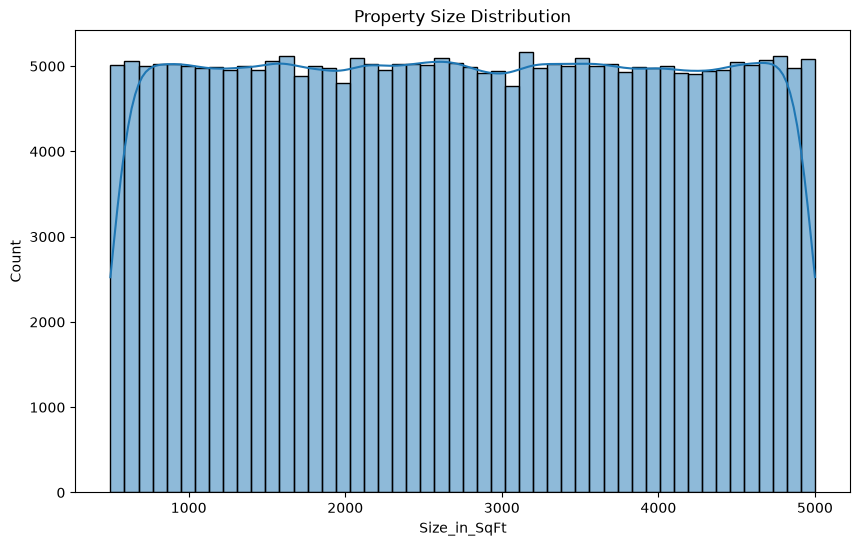

In [13]:
print(f"The skew of property pices is {raw_df['Size_in_SqFt'].skew()}")
plt.figure(figsize=(10,6))
plt.title("Property Size Distribution")
sns.histplot(data=raw_df,x="Size_in_SqFt",bins=50, kde=True)
plt.show()

#### Interpretation:
The property size distribution is approximately uniform and symmetric. The skewness is 0.0008, which is very close to zero, indicating no significant left or right skewness. Property sizes are evenly distributed between 500 and 5000 sq ft, with no dominant size range or noticeable skew.

#### 3. How does the price per sq ft vary by property type?

Property_Type
Apartment            0.130493
Independent House    0.131023
Villa                0.130276
Name: Price_per_SqFt, dtype: float64

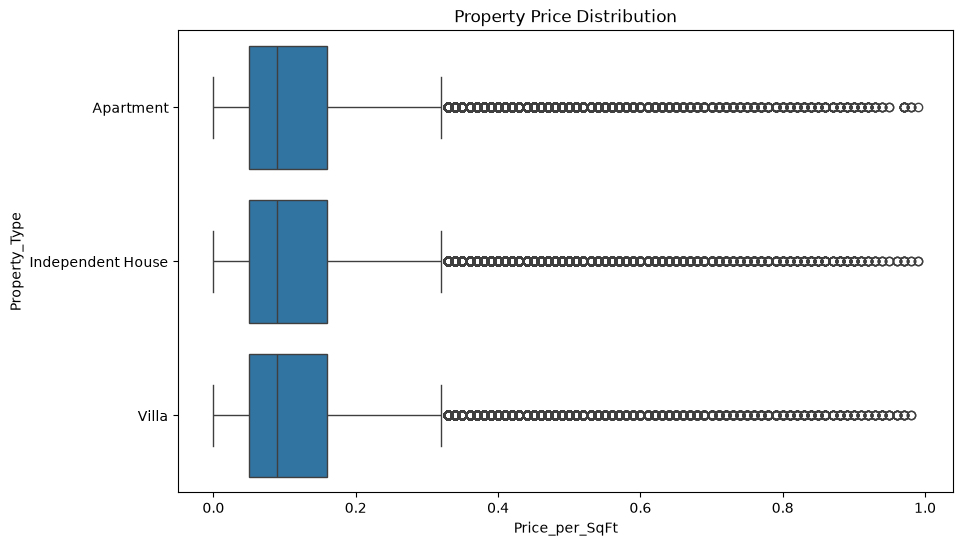

In [14]:
display(raw_df.groupby('Property_Type')['Price_per_SqFt'].mean())
plt.figure(figsize=(10,6))
plt.title("Property Price Distribution")
sns.boxplot(data=raw_df,y='Property_Type',x='Price_per_SqFt')
plt.show()

#### 4. Is there a relationship between property size and price?

The correlation between property size and price is -0.002529215932284042


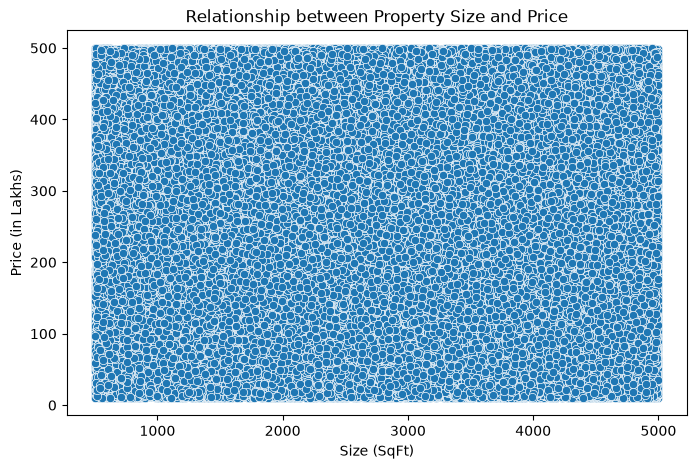

In [15]:
print(f"The correlation between property size and price is {raw_df['Size_in_SqFt'].corr(raw_df['Price_in_Lakhs'],method='spearman')}")
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=raw_df, 
    x='Size_in_SqFt', 
    y='Price_in_Lakhs'
)
plt.title('Relationship between Property Size and Price')
plt.xlabel('Size (SqFt)')
plt.ylabel('Price (in Lakhs)')
plt.show()

#### Interpretation
There is no significant relationship between property size and property price. The Spearman correlation coefficient is -0.0025, indicating an almost zero correlation. The scatter plot shows no clear trend, implying that larger properties are not necessarily more expensive in this dataset.

#### 5. Are there any outliers in price per sq ft or property size?

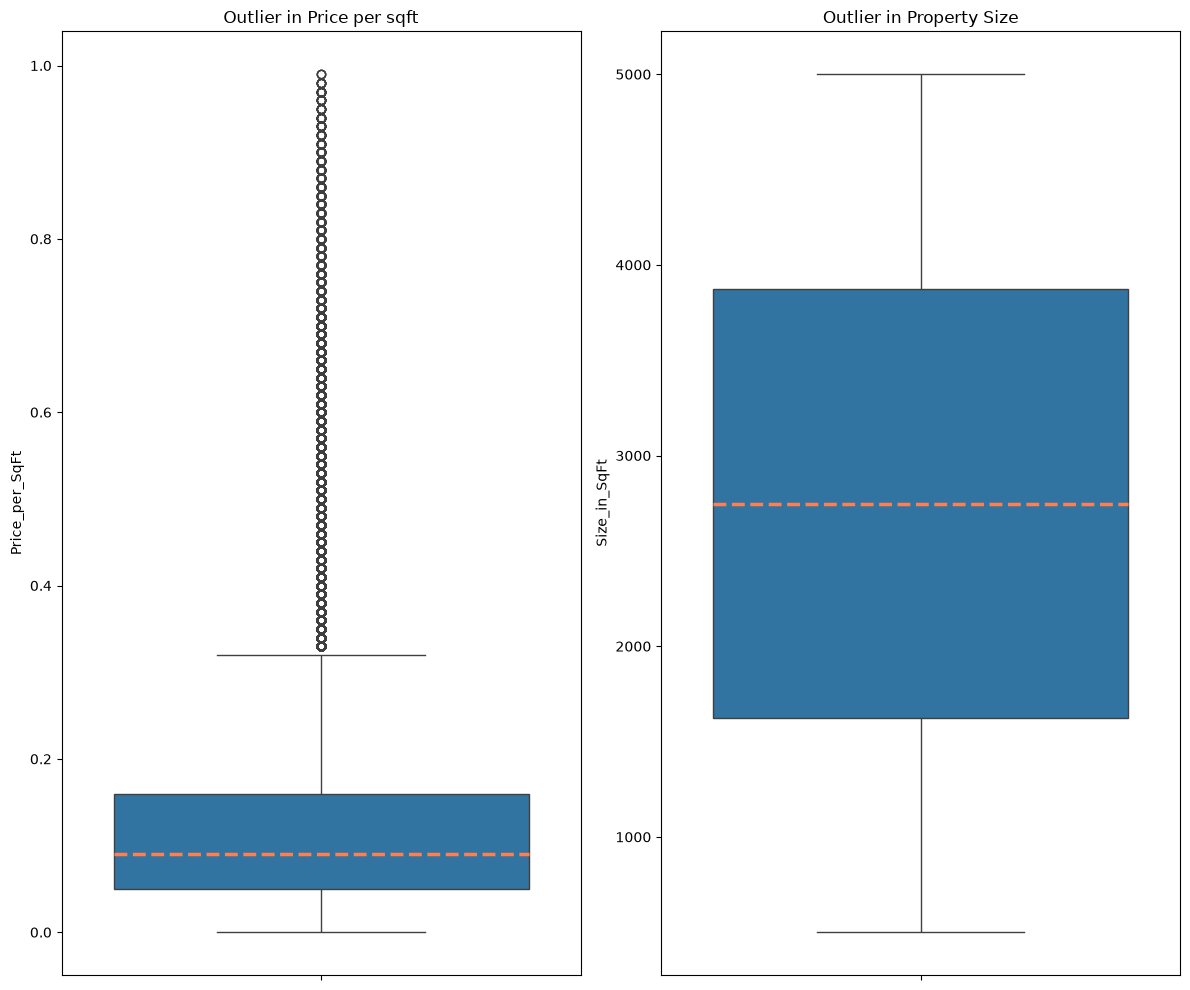

In [16]:
fig,axes = plt.subplots(nrows=1,ncols=2,figsize=(12, 10))
axes[0].set_title("Outlier in Price per sqft")
sns.boxplot(data=raw_df['Price_per_SqFt'],ax=axes[0],medianprops={"color": "coral", "linewidth": 2.5, "linestyle": "--"})
axes[1].set_title("Outlier in Property Size")
sns.boxplot(data=raw_df['Size_in_SqFt'],ax=axes[1],medianprops={"color": "coral", "linewidth": 2.5, "linestyle": "--"})
plt.tight_layout()
plt.show()

#### Interpretation
Price per Sq Ft contains several upper-end outliers, indicating a few properties are priced much higher per square foot than the majority. However, Property Size does not show any significant outliers based on the IQR method, suggesting that property sizes are evenly distributed without extreme values.

## 6–10: Location-based Analysis

#### 6. What is the average price per sq ft by state?

In [23]:
avg_price_sqft_state = raw_df.groupby('State').agg(Avg_price=("Price_per_SqFt", "mean")).reset_index()
display(avg_price_sqft_state)

,State,Avg_price
0,Andhra Pradesh,0.132037
1,Assam,0.130819
2,Bihar,0.130513
3,Chhattisgarh,0.130243
4,Delhi,0.129477
5,Gujarat,0.130995
6,Haryana,0.130692
7,Jharkhand,0.129754
8,Karnataka,0.132538
9,Kerala,0.129849
